In [51]:
#Библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay)
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## 1. Анализ и предобработка данных

In [52]:
#Загрузим датасет
df = pd.read_csv("water_potability.csv")

#"Чистим" названия столбцов
df.columns = df.columns.str.strip()

#Выведем размер датасета, кол-во дубликатов строк и строк с пропусками
print(f'Размер таблицы до подготовки данных:{df.shape}')
print(f'Количество дубликатов до подготовки = {df.duplicated().sum()}')
print(f'Количество строк с пропусками до подготовки = {df.isna().any(axis=1).sum()}') 

#Проверим фичи - выведем названия, кол-во и % пропусков, типы данных
info = pd.DataFrame({"missing":(df.isna().sum()),
                     "missing_%": (df.isna().mean() * 100).round(2),
                     "dtype": df.dtypes})
print(info.sort_values("missing_%", ascending=False))

# выведем уникальные значения категориального таргета
print("\nУникальные таргеты:")
print(df["Potability"].unique().tolist())

#смотрим распределение таргета
print(df["Potability"].value_counts()) 


df.head(5)

Размер таблицы до подготовки данных:(3276, 10)
Количество дубликатов до подготовки = 0
Количество строк с пропусками до подготовки = 1265
                 missing  missing_%    dtype
Sulfate              781      23.84  float64
ph                   491      14.99  float64
Trihalomethanes      162       4.95  float64
Hardness               0       0.00  float64
Chloramines            0       0.00  float64
Solids                 0       0.00  float64
Conductivity           0       0.00  float64
Organic_carbon         0       0.00  float64
Turbidity              0       0.00  float64
Potability             0       0.00    int64

Уникальные таргеты:
[0, 1]
Potability
0    1998
1    1278
Name: count, dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [53]:
df.describe() #смотрим статистику числовых фичей

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


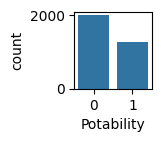

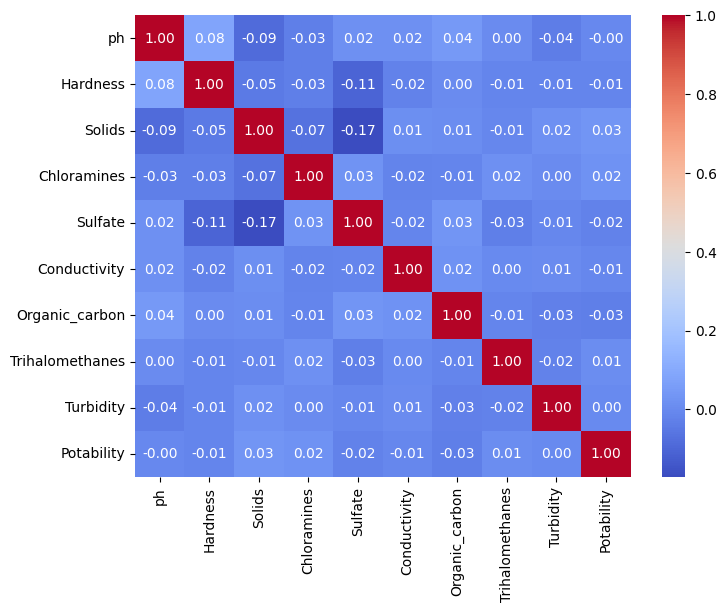

In [54]:
#график распределения целевой переменной
plt.figure(figsize=(1, 1))
sns.countplot(x="Potability", data=df)
plt.show()

#тепловая карта корреляции для числовых признаков 
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f')
plt.show()

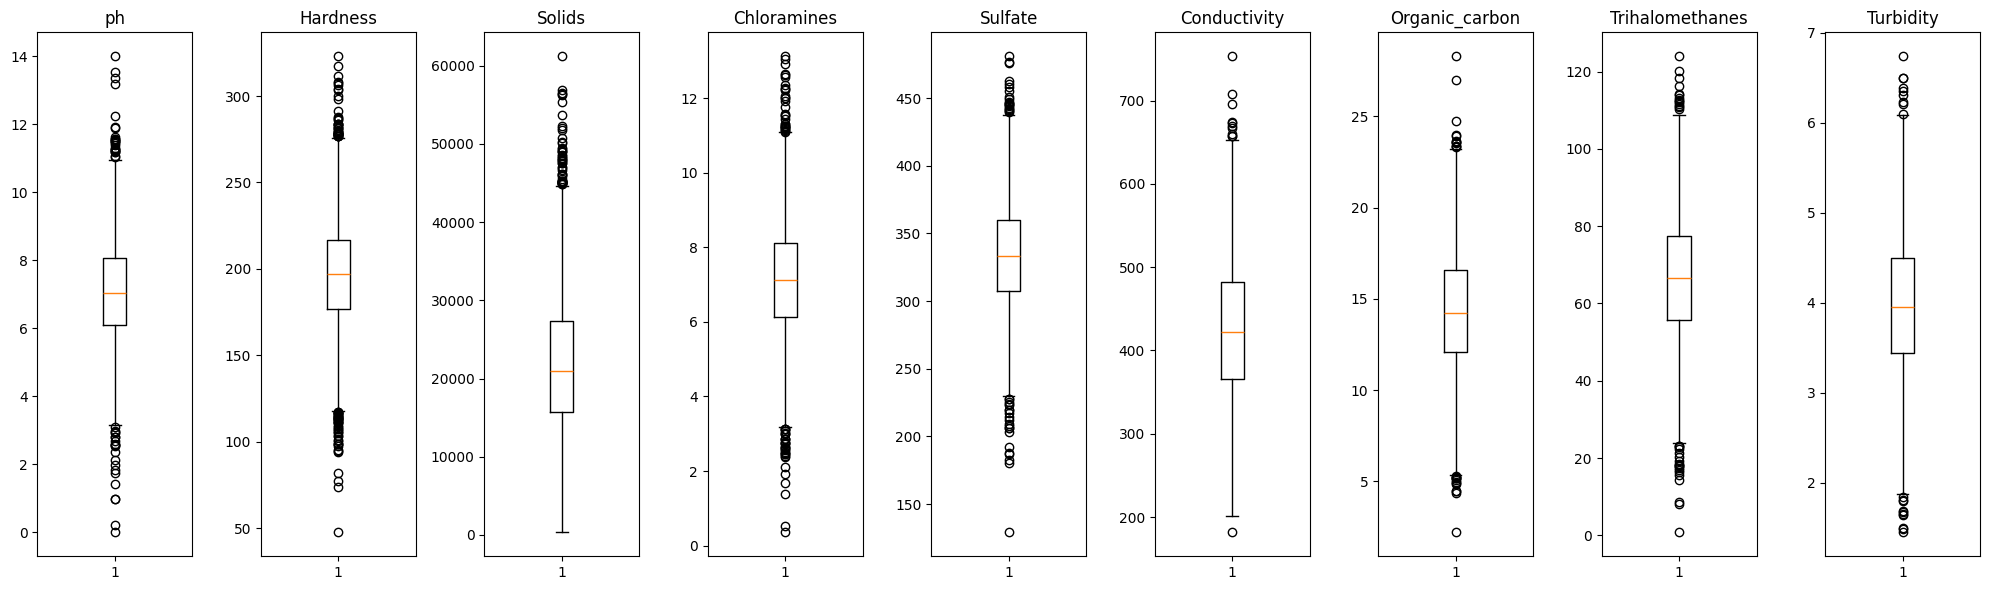

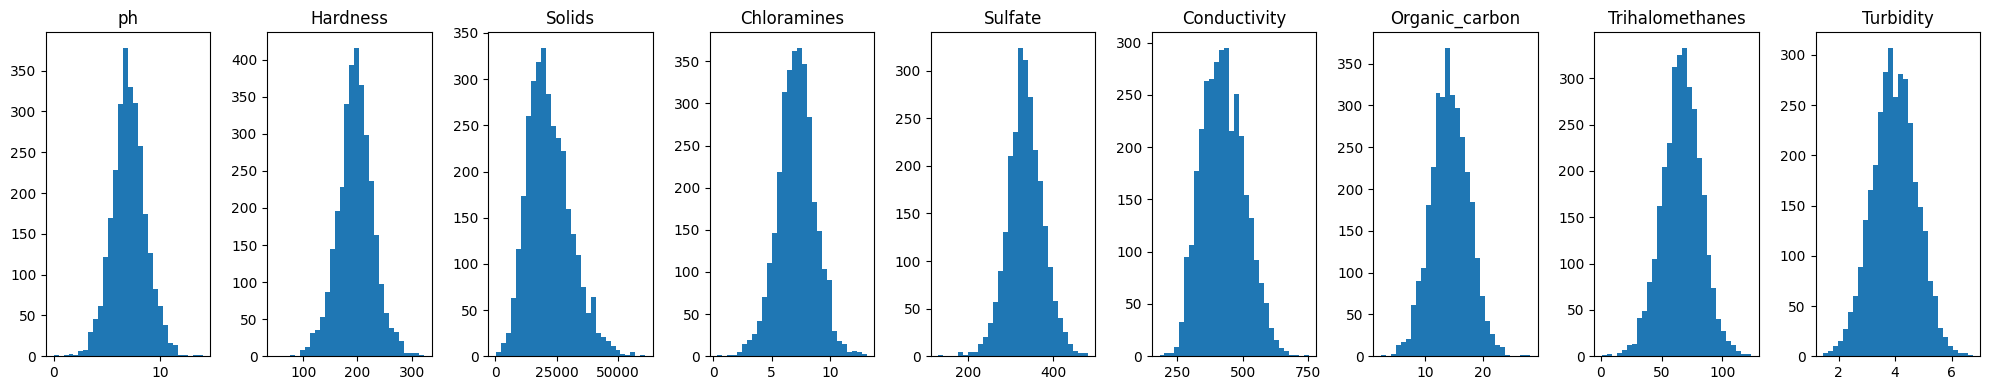

In [55]:
#Посмотрим на распределение признаков (гистограммы + ящики с усами)
unical = ["ph","Hardness",	"Solids","Chloramines",	"Sulfate","Conductivity","Organic_carbon","Trihalomethanes","Turbidity"]

# ящик с усами
fig, axs = plt.subplots(nrows=1, ncols=9, figsize=(20, 6))
for ax, uni in zip(axs, unical):
    ax.boxplot(df[uni].dropna())
    ax.set_title(uni)
plt.tight_layout()
plt.show()

# гистограммы
fig, axs = plt.subplots(1, 9, figsize=(20, 4))

for ax, uni in zip(axs, unical):
    ax.hist(df[uni], bins=30)
    ax.set_title(uni)

plt.tight_layout()
plt.show()

Вывод:
- Определили размер датасета
- Обнаружили, что все признаки числовые (таргет категориальный 1/0)
- Вывели статистику числовых фичей
- Обнаружили отсутствие дубликатов
- Обнаружили 3 признака с пропусками: Sulfate 781 (23.84%), ph 491 (14.99%),Trihalomethanes 162 (4.95%)
- Исходя из тепловой карты корреляций видим отсутствие признаков, коррелирующих с таргетом. Максимальная (по модулю) корреляция между фичами - Solids и Sulfate (-0,17), однако значение довольно низкое. Делаем вывод, что в данном эксперименте низка вероятность столкнуться с проблемой мультиколлинеарности
- Распределение таргета примерно 2 к 3 (1278 - 1, 1998 - 0)
- Распределение данных внутри признаков визуально близко к нормальному:
1) один выраженный максимум примерно в центре;
2) значения убывают по мере удаления от центра;
3) форма в целом напоминает колокол;
4) большинство распределений довольно симметричны;
5) нет ярко выраженной длинной асимметричной стороны.

## 2. БАЗОВЫЕ МОДЕЛИ. Логистическая регрессия, Метод опорных векторов (SVM), Дерево решений


In [56]:
#Создаем пайплайн для заполнения пропусков медианой (без индикации) и нормализации фичей. Обходимся без ColumnTransformer, так как все эти операции применимы ко всем фичам
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

X = df.drop(columns=["Potability"])     
y = df["Potability"]     

#Делим данные на train (80%) и test (20%) с stratify по целевой переменной
RANDOM_STATE = 42 #фиксируем случайность
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Логистическая регрессия
model_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))])

# SVM
model_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=42))])

# Решающее дерево. Нормализацию не проводим
model_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))])

model_logreg.fit(X_train, y_train)
model_svm.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

y_pred_logreg = model_logreg.predict(X_test)
y_pred_svm = model_svm.predict(X_test)
y_pred_tree = model_tree.predict(X_test)

y_score_logreg = model_logreg.predict_proba(X_test)[:, 1]
y_score_tree = model_tree.predict_proba(X_test)[:, 1]
y_score_svm = model_svm.decision_function(X_test)

metrics = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_logreg),
        roc_auc_score(y_test, y_score_logreg)],

    "SVM": [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_score(y_test, y_score_svm)],

    "Decision Tree": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree),
        roc_auc_score(y_test, y_score_tree)]}, 
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"])

metrics.round(3)

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Logistic Regression,SVM,Decision Tree
Accuracy,0.610,0.671,0.596
Precision,0.000,0.704,0.481
Recall,0.000,0.270,0.453
F1,0.000,0.390,0.467
ROC-AUC,0.548,0.649,0.570


Проведем те же операции используя кросс валидацию со стратификацией для 5 фолдов. Метрики при этом для каждой модели посчитаем train и valid

In [57]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc"}

cv_logreg = cross_validate(
    model_logreg,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_train_score=True)

cv_svm = cross_validate(
    model_svm,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_train_score=True)

cv_tree = cross_validate(
    model_tree,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_train_score=True)

#Собираем метрики (под тестом подразумевается результат метрики на валидационном фолде)
metrics_cv = pd.DataFrame({
    "LogReg Tr": [
        cv_logreg["train_Accuracy"].mean(),
        cv_logreg["train_Precision"].mean(),
        cv_logreg["train_Recall"].mean(),
        cv_logreg["train_F1"].mean(),
        cv_logreg["train_ROC-AUC"].mean()],
    
    "LogReg Val": [
        cv_logreg["test_Accuracy"].mean(),
        cv_logreg["test_Precision"].mean(),
        cv_logreg["test_Recall"].mean(),
        cv_logreg["test_F1"].mean(),
        cv_logreg["test_ROC-AUC"].mean()],

    "SVM Tr": [
        cv_svm["train_Accuracy"].mean(),
        cv_svm["train_Precision"].mean(),
        cv_svm["train_Recall"].mean(),
        cv_svm["train_F1"].mean(),
        cv_svm["train_ROC-AUC"].mean()],

    "SVM Val": [
        cv_svm["test_Accuracy"].mean(),
        cv_svm["test_Precision"].mean(),
        cv_svm["test_Recall"].mean(),
        cv_svm["test_F1"].mean(),
        cv_svm["test_ROC-AUC"].mean()],

    "Tree Tr": [
        cv_tree["train_Accuracy"].mean(),
        cv_tree["train_Precision"].mean(),
        cv_tree["train_Recall"].mean(),
        cv_tree["train_F1"].mean(),
        cv_tree["train_ROC-AUC"].mean()],

    "Tree Val": [
        cv_tree["test_Accuracy"].mean(),
        cv_tree["test_Precision"].mean(),
        cv_tree["test_Recall"].mean(),
        cv_tree["test_F1"].mean(),
        cv_tree["test_ROC-AUC"].mean()]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"])

metrics_cv.round(3)

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584
Precision,0.543,0.100,0.850,0.703,1.0,0.467
Recall,0.004,0.002,0.382,0.286,1.0,0.476
F1,0.007,0.003,0.527,0.406,1.0,0.471
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564


Сделаем выводы:
1) Логистическая регрессия:
- практически нулевые показатели всех метрик, за исключением Accuracy и ROC AUC + предупреждение о том, что модель не предсказала ни одного объекта класса 1. При этом Accuracy = 0.611 и ROC-AUC = 0.532	. С учетом того, что дисбаланс классов таргета не сильный (2 к 3), это может означать, что что логистическая регрессия практически не нашла в признаках линейного сигнала, позволяющего верно классифицировать объект.
- bias (смещение) очень высокое,  модель явно недообучена, variance (дисперсия) в основном низкая (за исключением Precision)
2) SVM:
- bias (смещение) умеренное. variance (дисперсия) умеренная - значения метрик на тренировочной и валидационной выборках отличаются, но не так глобально, как у дерева.
3) Решающее дерево:
- bias (смещение) низкий, variance (дисперсия) высокая - значения метрик на тренировочной и валидационной выборках сильно отличаются.

То есть результаты модели SVM гораздо лучше с точки зрения концепции bias-variance tradeoff (компромисс между смещением и дисперсией)

## 3. БЭГГИНГ

In [58]:
#Реализуем bagging над деревом
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

#Собираем пайплайн
bagging_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42))])

#Задаем сетку параметров
param_grid = {
    "classifier__n_estimators": [10, 25, 50, 75, 100],
    "classifier__max_samples": [0.6, 0.8, 1.0],
    "classifier__max_features": [0.6, 0.8, 1.0]}

#Стратифицированная кросс валидация
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

#GridSearchCV для определения оптимальной комбинации гиперпараметров по критерию ROC AUC
grid_bagging = GridSearchCV(
    estimator=bagging_model,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

#Обучаем
grid_bagging.fit(X_train, y_train)

#Смотрим лучшие параметры
print(grid_bagging.best_params_)

#Получаем индекс оптимальной камбинации
best_idx = grid_bagging.best_index_

#Дополняем нашу таблицу метрик
results = grid_bagging.cv_results_

metrics_cv["Bagging Tr"] = [
    results["mean_train_Accuracy"][best_idx],
    results["mean_train_Precision"][best_idx],
    results["mean_train_Recall"][best_idx],
    results["mean_train_F1"][best_idx],
    results["mean_train_ROC-AUC"][best_idx]]

metrics_cv["Bagging Val"] = [
    results["mean_test_Accuracy"][best_idx],
    results["mean_test_Precision"][best_idx],
    results["mean_test_Recall"][best_idx],
    results["mean_test_F1"][best_idx],
    results["mean_test_ROC-AUC"][best_idx]]

metrics_cv.round(3)

{'classifier__max_features': 1.0, 'classifier__max_samples': 1.0, 'classifier__n_estimators': 100}


,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692


Мы провели bagging с моделью решающего дерева. Выводы:
1) GridSearchCV определил оптимальные гиперпараметры (критерий - ROC AUC). 
- Кол-во моделей (деревьев) - 100 (максимальное в диапазоне).
- Кол-во вытягиваний - 100% (то есть равное числу объектов)
- Кол-во фичей - 100% (то есть не ограничиваем наше кол-во фичей)
2) По сравнению с одним решающим деревом бэггинг позволил значительно улучшить следующие метрики: Accuracy, Precision, ROC-AUC. То есть bias (смещение) осталось низким, но при этом variance (дисперсия) понизилась.
3) По сравнению с SVM у бэггинга над деревьями все метрики оказались выше.

## 4. СЛУЧАЙНЫЙ ЛЕС

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(random_state=42))])

# Сетка параметров
param_grid_rf = {
    "classifier__n_estimators": [50, 100, 150, 200],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__max_features": ["sqrt", "log2", None]}

# GridSearch
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

# Обучаем только на train
grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

best_idx_rf = grid_rf.best_index_
results_rf = grid_rf.cv_results_

metrics_cv["RF Tr"] = [
    results_rf["mean_train_Accuracy"][best_idx_rf],
    results_rf["mean_train_Precision"][best_idx_rf],
    results_rf["mean_train_Recall"][best_idx_rf],
    results_rf["mean_train_F1"][best_idx_rf],
    results_rf["mean_train_ROC-AUC"][best_idx_rf]]

metrics_cv["RF Val"] = [
    results_rf["mean_test_Accuracy"][best_idx_rf],
    results_rf["mean_test_Precision"][best_idx_rf],
    results_rf["mean_test_Recall"][best_idx_rf],
    results_rf["mean_test_F1"][best_idx_rf],
    results_rf["mean_test_ROC-AUC"][best_idx_rf]]

metrics_cv.round(3)

{'classifier__max_depth': 15, 'classifier__max_features': None, 'classifier__n_estimators': 150}


,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val,RF Tr,RF Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676,0.974,0.684
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643,1.000,0.680
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379,0.934,0.356
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476,0.966,0.467
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692,1.000,0.694


Random Forest. Выводы:
1) GridSearchCV определил оптимальные гиперпараметры (критерий - ROC AUC). 
- Кол-во моделей (деревьев) - 150.
- Максимальная глубина одного дерева - 15
- Кол-во фичей - None (то есть не ограничиваем наше кол-во фичей). То есть при каждом split дерево рассматривает все признаки. Но одна из главных особенностей Random Forest по сравнению с обычным bagging — случайное ограничение числа признаков при каждом split. GridSearch показал, что на этом датасете из предложенных вариантов лучший ROC-AUC получается, когда я НЕ ограничиваю признаки на split». И поэтому неудивительно, что результаты Bagging и RF практически совпали.
1) По сравнению с SVM улучшились все метрики. 
2) По сравнению с бэггингом над деревьями случайный лес позволил незначительно улучшить следующие метрики: Accuracy, Precision, ROC-AUC. Но уменьшились метрики Recall и F1. То есть Random Forest стал более консервативно предсказывать класс 1.


           Feature  Importance
0               ph    0.145627
4          Sulfate    0.140023
1         Hardness    0.125066
3      Chloramines    0.125037
2           Solids    0.112306
5     Conductivity    0.094813
8        Turbidity    0.089338
7  Trihalomethanes    0.084376
6   Organic_carbon    0.083414


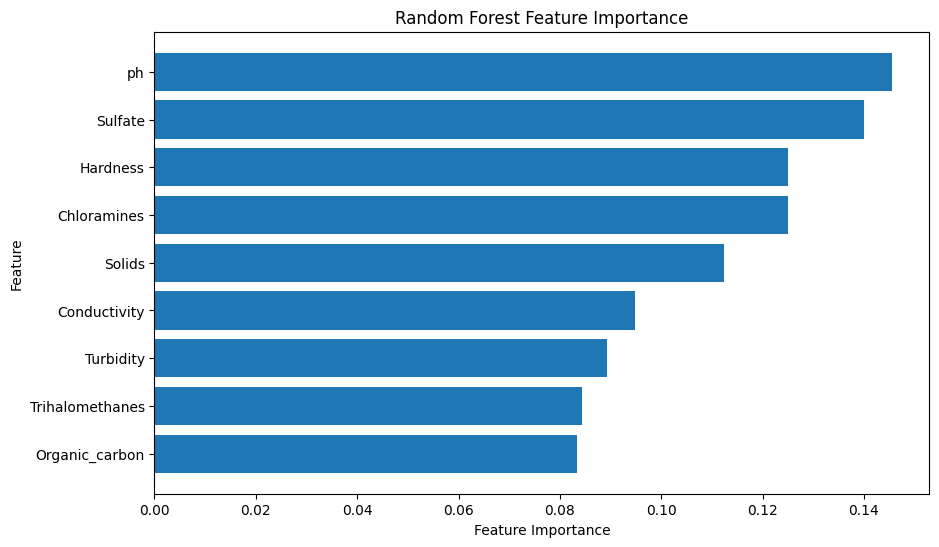

In [60]:
# Достаем лучшую модель Random Forest из GridSearch
best_rf_model = grid_rf.best_estimator_

# Достаем сам RandomForestClassifier из Pipeline
best_rf = best_rf_model.named_steps["classifier"]

# Создаем таблицу важности признаков
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_})

# Оставляем только признаки с ненулевой важностью и сортируем по важности
feature_importance_rf = (
    feature_importance_rf[
        feature_importance_rf["Importance"] != 0]
    .sort_values("Importance", ascending=False))

# Выводим таблицу
print(feature_importance_rf)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_rf["Feature"],
    feature_importance_rf["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

# Самый важный признак будет сверху
plt.gca().invert_yaxis()

plt.show()

Мы анализируем именно встроенную в Random Forest важность. Она основана на том, насколько использование каждого признака в сплитах деревьев в среднем уменьшало impurity (по критерию Gini по умолчанию). Видим, что на качество воды влияют 9 признаков, при этом их влияние соизмеримо. Сравним с важностью признаков по permutation_importance

           Feature  Importance
0               ph    0.110534
4          Sulfate    0.104962
1         Hardness    0.055574
3      Chloramines    0.044997
2           Solids    0.024276
5     Conductivity    0.008751
7  Trihalomethanes    0.006563
8        Turbidity    0.003381
6   Organic_carbon    0.001054


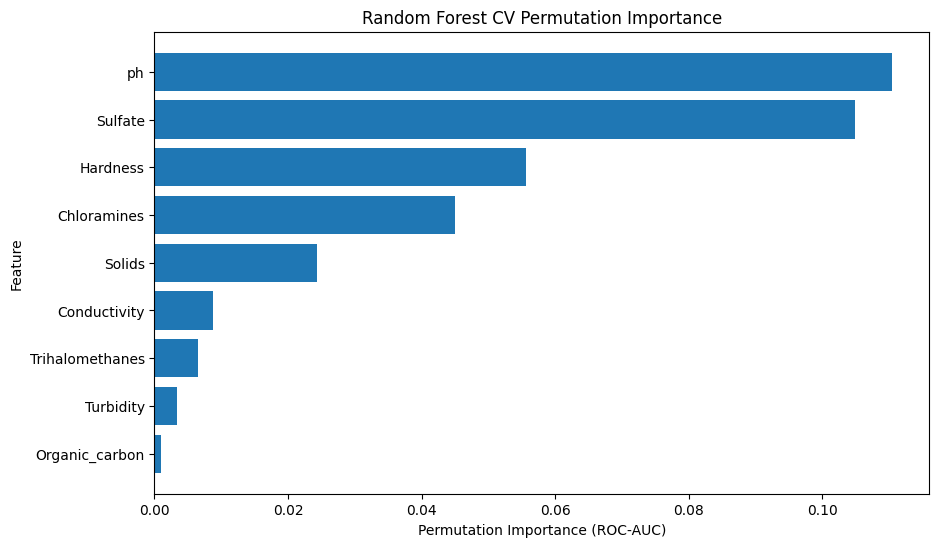

In [61]:
from sklearn.base import clone

# Здесь будем хранить importance каждого фолда
fold_importances = []

# Проходим по тем же CV-фолдам
for train_idx, val_idx in skf.split(X_train, y_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Копируем лучшую модель
    rf_fold = clone(grid_rf.best_estimator_)

    # Обучаем только на train-части фолда
    rf_fold.fit(X_tr, y_tr)

    # Permutation Importance только на validation-части
    perm = permutation_importance(
        rf_fold,
        X_val,
        y_val,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1)

    fold_importances.append(perm.importances_mean)

# усредняем результаты пяти validation-фолдов
mean_importance = np.mean(fold_importances, axis=0)

perm_df_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": mean_importance
}).sort_values("Importance", ascending=False)

perm_df_rf_not_zero = perm_df_rf[
    perm_df_rf["Importance"] != 0]

print(perm_df_rf_not_zero)

#График
plt.figure(figsize=(10, 6))

plt.barh(
    perm_df_rf_not_zero["Feature"],
    perm_df_rf_not_zero["Importance"])

plt.xlabel("Permutation Importance (ROC-AUC)")
plt.ylabel("Feature")
plt.title("Random Forest CV Permutation Importance")

plt.gca().invert_yaxis()
plt.show()

Анализ встроенной важности признаков Random Forest и permutation importance показывает согласованность методов относительно наиболее значимых признаков. Наибольшее влияние на прогноз модели оказывают pH и Sulfate, далее следуют Hardness и Chloramines. При этом встроенная важность Random Forest распределена между признаками значительно равномернее, тогда как permutation importance показывает, что нарушение информации в ряде признаков (Organic_carbon, Turbidity, Trihalomethanes) практически не снижает ROC-AUC на валидационных данных. Это указывает на то, что использование признака деревьями при построении сплитов не обязательно означает его высокую самостоятельную ценность для обобщающей способности модели.

Для данного датасета Random Forest не продемонстрировал существенного преимущества перед простым бэггингом решающих деревьев.   
Значения ROC-AUC на кросс-валидации практически совпадают: 0.694 для Random Forest против 0.692 для Bagging. При этом GridSearchCV выбрал для Random Forest max_features=None, то есть на каждом разбиении дерева рассматривались все доступные признаки.   
Таким образом, дополнительная рандомизация признакового пространства — один из ключевых механизмов Random Forest, отличающих его от обычного bagging, — в данном случае не улучшила качество модели.   
Вероятно, для этого датасета основное преимущество ансамблирования достигается за счёт bootstrap-выборок и усреднения большого количества деревьев, тогда как дополнительное ограничение признаков на каждом сплите не даёт заметного выигрыша.

## 5. AdaBoost

In [62]:
from sklearn.ensemble import AdaBoostClassifier

#Пайплайн 
ada_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", AdaBoostClassifier(random_state=42))])

#Сетка гиперпараметров
param_grid_ada = {
    "classifier__n_estimators": [25, 50, 75, 100, 150, 200],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0]}

#Подбор гиперпараметров по критерию ROC AUC
grid_ada = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid_ada,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

#Обучение
grid_ada.fit(X_train, y_train)

#Лучшие гиперпараметры
print(grid_ada.best_params_)

#достаем лучшие параметры
best_idx_ada = grid_ada.best_index_
results_ada = grid_ada.cv_results_

metrics_cv["AB Tr"] = [
    results_ada["mean_train_Accuracy"][best_idx_ada],
    results_ada["mean_train_Precision"][best_idx_ada],
    results_ada["mean_train_Recall"][best_idx_ada],
    results_ada["mean_train_F1"][best_idx_ada],
    results_ada["mean_train_ROC-AUC"][best_idx_ada]]

metrics_cv["AB Val"] = [
    results_ada["mean_test_Accuracy"][best_idx_ada],
    results_ada["mean_test_Precision"][best_idx_ada],
    results_ada["mean_test_Recall"][best_idx_ada],
    results_ada["mean_test_F1"][best_idx_ada],
    results_ada["mean_test_ROC-AUC"][best_idx_ada]]

metrics_cv.round(3)

{'classifier__learning_rate': 0.2, 'classifier__n_estimators': 50}


,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val,RF Tr,RF Val,AB Tr,AB Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676,0.974,0.684,0.623,0.622
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643,1.000,0.680,0.742,0.730
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379,0.934,0.356,0.052,0.049
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476,0.966,0.467,0.097,0.092
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692,1.000,0.694,0.587,0.570


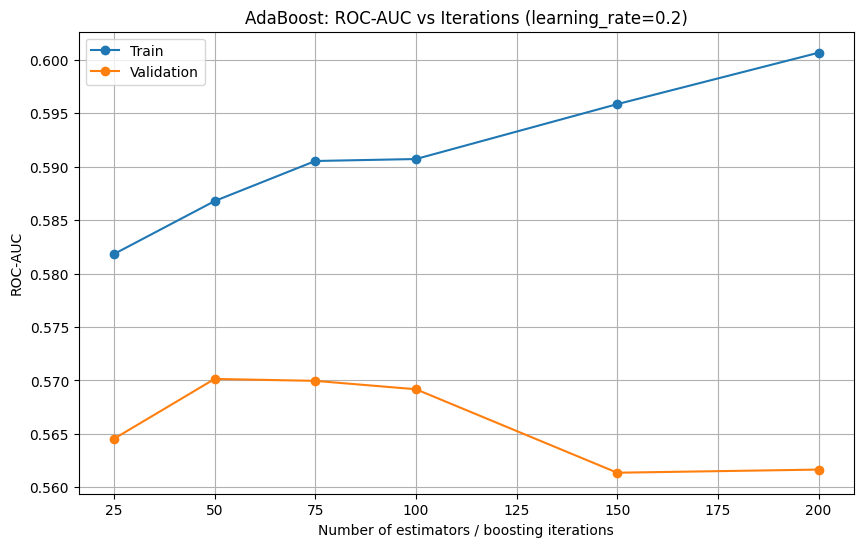

In [63]:
#Для визуализации ROC AUC от числа итераций зафиксируем лучший learning_rate

best_lr = grid_ada.best_params_["classifier__learning_rate"]

ada_results = pd.DataFrame(grid_ada.cv_results_)

ada_curve = ada_results[
    ada_results["param_classifier__learning_rate"] == best_lr
].sort_values("param_classifier__n_estimators")

plt.figure(figsize=(10, 6))

plt.plot(
    ada_curve["param_classifier__n_estimators"],
    ada_curve["mean_train_ROC-AUC"],
    marker="o",
    label="Train")

plt.plot(
    ada_curve["param_classifier__n_estimators"],
    ada_curve["mean_test_ROC-AUC"],
    marker="o",
    label="Validation")

plt.xlabel("Number of estimators / boosting iterations")
plt.ylabel("ROC-AUC")
plt.title(f"AdaBoost: ROC-AUC vs Iterations (learning_rate={best_lr})")

plt.legend()
plt.grid()

plt.show()

При увеличении количества итераций AdaBoost качество на обучающей выборке последовательно возрастает, тогда как ROC-AUC на валидационной выборке достигает максимума примерно при 50 моделях, после чего начинает снижаться. Это свидетельствует о начале переобучения: дальнейшее добавление слабых моделей улучшает подгонку под обучающие данные, но не улучшает обобщающую способность ансамбля. При этом максимальный валидационный ROC-AUC составляет лишь около 0.57, что существенно ниже результатов SVM, Bagging и Random Forest.   
Следовательно, для данного датасета AdaBoost с базовыми деревьями глубины 1 демонстрирует сравнительно высокий bias, а увеличение числа итераций после определённого момента приводит также к росту variance.
Однако это может быть связано с тем, что по умолчанию глубина каждого дерева равна 1. То есть по сутим мы используем слишком слабые модели. Проверим это предположение.

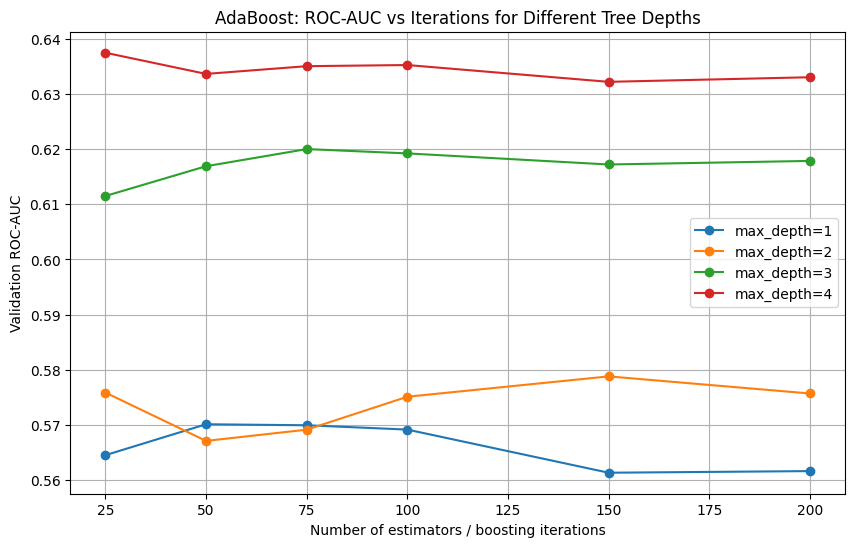

In [64]:
ada_depth = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        learning_rate=0.2,   #фиксируем
        random_state=42))])

param_grid_depth = {
    "classifier__n_estimators": [25, 50, 75, 100, 150, 200],
    "classifier__estimator__max_depth": [1, 2, 3, 4]}

grid_ada_depth = GridSearchCV(
    estimator=ada_depth,
    param_grid=param_grid_depth,
    scoring="roc_auc",
    cv=skf,
    return_train_score=True,
    n_jobs=-1)

grid_ada_depth.fit(X_train, y_train)

ada_depth_results = pd.DataFrame(grid_ada_depth.cv_results_)

plt.figure(figsize=(10, 6))

for depth in [1, 2, 3, 4]:

    data = ada_depth_results[
        ada_depth_results["param_classifier__estimator__max_depth"] == depth
    ].sort_values("param_classifier__n_estimators")

    plt.plot(
        data["param_classifier__n_estimators"],
        data["mean_test_score"],
        marker="o",
        label=f"max_depth={depth}"
    )

plt.xlabel("Number of estimators / boosting iterations")
plt.ylabel("Validation ROC-AUC")
plt.title("AdaBoost: ROC-AUC vs Iterations for Different Tree Depths")
plt.legend()
plt.grid()

plt.show()

Действительно, низкий ROC AUC в первом варианте был связан с ограничением глубины деревьев. Выяснили это для себя, но т.к. по заданию необходимо было подобрать только n_estimators и learning_rate, то в результатах оставим результат первой модели с depth=1.

## 6. ГРАДИЕНТНЫЙ БУСТИНГ

In [65]:
#Градиентный бустинг
from sklearn.ensemble import GradientBoostingClassifier

# Модель
gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", GradientBoostingClassifier(random_state=42))])

# Сетка гиперпараметров
param_grid_gb = {
    "classifier__n_estimators": [25, 50, 75, 100, 150, 200],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0],
    "classifier__max_depth": [1, 2, 3, 4, 5]}

# GridSearchCV
grid_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

# Обучение
grid_gb.fit(X_train, y_train)

# Лучшие параметры
print(grid_gb.best_params_)

best_idx_gb = grid_gb.best_index_
results_gb = grid_gb.cv_results_

metrics_cv["GB Tr"] = [
    results_gb["mean_train_Accuracy"][best_idx_gb],
    results_gb["mean_train_Precision"][best_idx_gb],
    results_gb["mean_train_Recall"][best_idx_gb],
    results_gb["mean_train_F1"][best_idx_gb],
    results_gb["mean_train_ROC-AUC"][best_idx_gb]]

metrics_cv["GB Val"] = [
    results_gb["mean_test_Accuracy"][best_idx_gb],
    results_gb["mean_test_Precision"][best_idx_gb],
    results_gb["mean_test_Recall"][best_idx_gb],
    results_gb["mean_test_F1"][best_idx_gb],
    results_gb["mean_test_ROC-AUC"][best_idx_gb]]

metrics_cv.round(3)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 75}


,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val,RF Tr,RF Val,AB Tr,AB Val,GB Tr,GB Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676,0.974,0.684,0.623,0.622,0.866,0.661
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643,1.000,0.680,0.742,0.730,0.985,0.626
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379,0.934,0.356,0.052,0.049,0.667,0.327
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476,0.966,0.467,0.097,0.092,0.795,0.428
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692,1.000,0.694,0.587,0.570,0.971,0.653


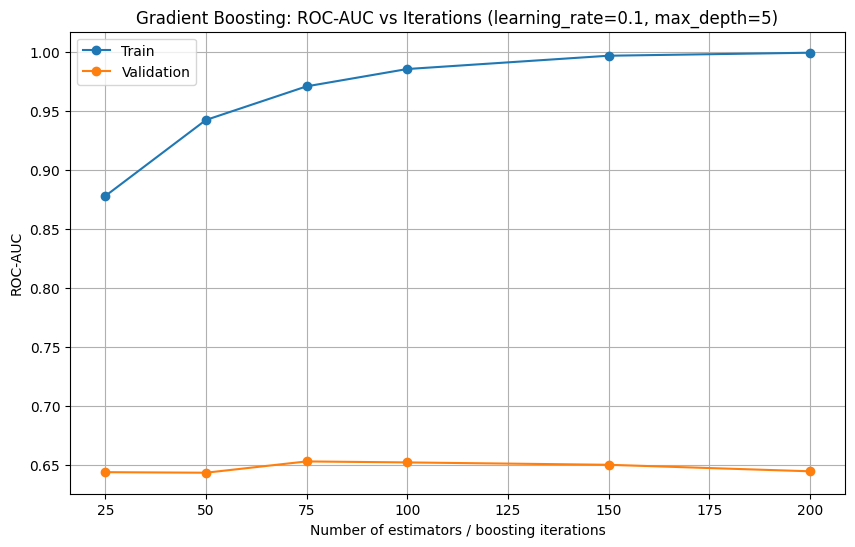

In [ ]:
gb_results = pd.DataFrame(grid_gb.cv_results_)

gb_curve = gb_results[
    (gb_results["param_classifier__learning_rate"] == 0.1)
    &
    (gb_results["param_classifier__max_depth"] == 5)
].sort_values("param_classifier__n_estimators")

plt.figure(figsize=(10, 6))

plt.plot(
    gb_curve["param_classifier__n_estimators"],
    gb_curve["mean_train_ROC-AUC"],
    marker="o",
    label="Train")

plt.plot(
    gb_curve["param_classifier__n_estimators"],
    gb_curve["mean_test_ROC-AUC"],
    marker="o",
    label="Validation")

plt.xlabel("Number of estimators / boosting iterations")
plt.ylabel("ROC-AUC")
plt.title(
    "Gradient Boosting: ROC-AUC vs Iterations "
    "(learning_rate=0.1, max_depth=5)")

plt.legend()
plt.grid()
plt.show()

При увеличении количества базовых моделей Gradient Boosting наблюдается последовательный рост ROC-AUC на обучающей выборке.    
При этом ROC-AUC на валидационных данных остаётся в диапазоне и достигает максимума примерно при 75 итерациях. Значительный разрыв между обучающей и валидационной метриками свидетельствует о высокой дисперсии модели и выраженном переобучении. После ~75 итераций дальнейшее увеличение числа деревьев не улучшает обобщающую способность и лишь усиливает подгонку под обучающие данные.

## 7. XGBoost

In [69]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=1)

param_grid_xgb = {
    "n_estimators": [25, 50, 75, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0],
    "max_depth": [1, 2, 3, 4, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)

best_idx_xgb = grid_xgb.best_index_
results_xgb = grid_xgb.cv_results_

metrics_cv["XGB Tr"] = [
    results_xgb["mean_train_Accuracy"][best_idx_xgb],
    results_xgb["mean_train_Precision"][best_idx_xgb],
    results_xgb["mean_train_Recall"][best_idx_xgb],
    results_xgb["mean_train_F1"][best_idx_xgb],
    results_xgb["mean_train_ROC-AUC"][best_idx_xgb]]

metrics_cv["XGB Val"] = [
    results_xgb["mean_test_Accuracy"][best_idx_xgb],
    results_xgb["mean_test_Precision"][best_idx_xgb],
    results_xgb["mean_test_Recall"][best_idx_xgb],
    results_xgb["mean_test_F1"][best_idx_xgb],
    results_xgb["mean_test_ROC-AUC"][best_idx_xgb]]

metrics_cv.round(3)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}


,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val,RF Tr,RF Val,AB Tr,AB Val,GB Tr,GB Val,XGB Tr,XGB Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676,0.974,0.684,0.623,0.622,0.866,0.661,0.741,0.661
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643,1.000,0.680,0.742,0.730,0.985,0.626,0.937,0.717
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379,0.934,0.356,0.052,0.049,0.667,0.327,0.360,0.215
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476,0.966,0.467,0.097,0.092,0.795,0.428,0.520,0.330
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692,1.000,0.694,0.587,0.570,0.971,0.653,0.885,0.683


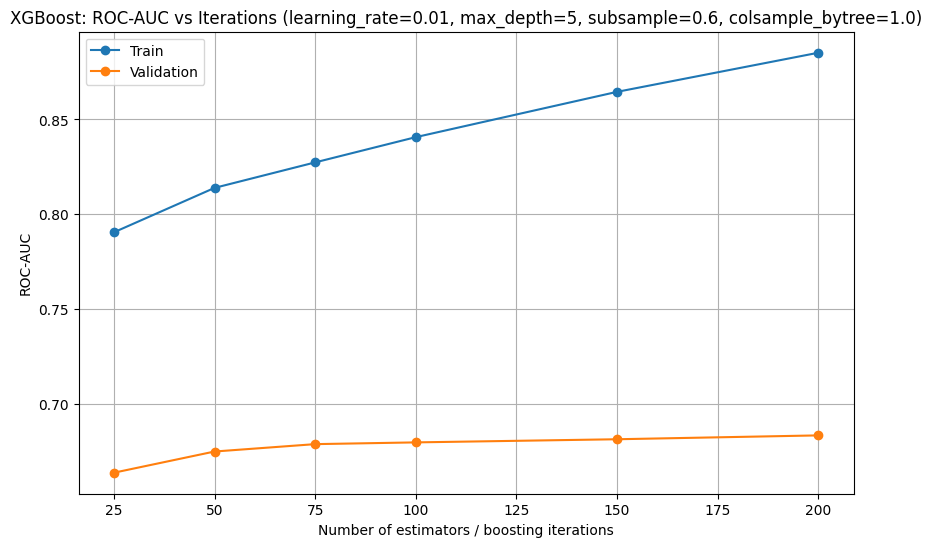

In [ ]:
#Построим график зависимости метрики от числа итераций
xgb_results = pd.DataFrame(grid_xgb.cv_results_)

best_lr = grid_xgb.best_params_["learning_rate"]
best_depth = grid_xgb.best_params_["max_depth"]
best_subsample = grid_xgb.best_params_["subsample"]
best_colsample = grid_xgb.best_params_["colsample_bytree"]

xgb_curve = xgb_results[
    (xgb_results["param_learning_rate"] == best_lr)
    &
    (xgb_results["param_max_depth"] == best_depth)
    &
    (xgb_results["param_subsample"] == best_subsample)
    &
    (xgb_results["param_colsample_bytree"] == best_colsample)
].sort_values("param_n_estimators")

plt.figure(figsize=(10, 6))

plt.plot(
    xgb_curve["param_n_estimators"],
    xgb_curve["mean_train_ROC-AUC"],
    marker="o",
    label="Train")

plt.plot(
    xgb_curve["param_n_estimators"],
    xgb_curve["mean_test_ROC-AUC"],
    marker="o",
    label="Validation")

plt.xlabel("Number of estimators / boosting iterations")
plt.ylabel("ROC-AUC")

plt.title(
    f"XGBoost: ROC-AUC vs Iterations "
    f"(learning_rate={best_lr}, "
    f"max_depth={best_depth}, "
    f"subsample={best_subsample}, "
    f"colsample_bytree={best_colsample})")

plt.legend()
plt.grid()
plt.show()

XGBoost ведёт себя лучше, чем Gradient Boosting с точки зрения контроля переобучения, но проблема variance всё равно заметна. Т.к. learning_rate довольно низкий, зафиксируем все параметры, и попробуем подобрать n_estimators.

In [72]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=1)

param_grid_xgb = {
    "n_estimators": [100, 200, 300, 400, 500, 750, 1000],
    "learning_rate": [0.01],
    "max_depth": [5],
    "subsample": [0.6],
    "colsample_bytree": [1.0]}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

best_idx_xgb = grid_xgb.best_index_
results_xgb = grid_xgb.cv_results_

metrics_cv["XGB Tr"] = [
    results_xgb["mean_train_Accuracy"][best_idx_xgb],
    results_xgb["mean_train_Precision"][best_idx_xgb],
    results_xgb["mean_train_Recall"][best_idx_xgb],
    results_xgb["mean_train_F1"][best_idx_xgb],
    results_xgb["mean_train_ROC-AUC"][best_idx_xgb]]

metrics_cv["XGB Val"] = [
    results_xgb["mean_test_Accuracy"][best_idx_xgb],
    results_xgb["mean_test_Precision"][best_idx_xgb],
    results_xgb["mean_test_Recall"][best_idx_xgb],
    results_xgb["mean_test_F1"][best_idx_xgb],
    results_xgb["mean_test_ROC-AUC"][best_idx_xgb]]

metrics_cv.round(3)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.6}
0.6883861798456288


,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val,RF Tr,RF Val,AB Tr,AB Val,GB Tr,GB Val,XGB Tr,XGB Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676,0.974,0.684,0.623,0.622,0.866,0.661,0.933,0.673
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643,1.000,0.680,0.742,0.730,0.985,0.626,0.979,0.634
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379,0.934,0.356,0.052,0.049,0.667,0.327,0.847,0.383
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476,0.966,0.467,0.097,0.092,0.795,0.428,0.908,0.475
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692,1.000,0.694,0.587,0.570,0.971,0.653,0.991,0.688


Для XGBoost оптимальной среди исследованных конфигураций оказалась модель с learning_rate=0.01, max_depth=5, subsample=0.6, colsample_bytree=1.0 и n_estimators=1000.   
Увеличение числа boosting-итераций с 200 до 1000 позволило повысить валидационный ROC-AUC, что подтверждает необходимость большего количества слабых шагов при низком learning rate. При этом наблюдается значительный разрыв между обучающим и валидационным качеством, что свидетельствует о высокой дисперсии модели и переобучении. 
Несмотря на это, XGBoost показывает значительно более высокое качество по сравнению с AdaBoost и Gradient Boosting, однако для данного датасета не превосходит Random Forest и Bagging по валидационному ROC-AUC.

## 8. СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

In [73]:
metrics_val = metrics_cv.filter(like="Val")

metrics_val.round(3)

,LogReg Val,SVM Val,Tree Val,Bagging Val,RF Val,AB Val,GB Val,XGB Val
Accuracy,0.610,0.674,0.584,0.676,0.684,0.622,0.661,0.673
Precision,0.100,0.703,0.467,0.643,0.680,0.730,0.626,0.634
Recall,0.002,0.286,0.476,0.379,0.356,0.049,0.327,0.383
F1,0.003,0.406,0.471,0.476,0.467,0.092,0.428,0.475
ROC-AUC,0.500,0.688,0.564,0.692,0.694,0.570,0.653,0.688


Сравнивать скорость обучения сложно, т.к. я для каждой модели подбирал гиперпараметры через GridSearch (время, потраченное на обучение сильно зависило от количества подбираемых гиперпараметров и их диапазонов).

Что касается важности гиперпараметров - очевидно, что их подбор оказывает огромное влияние на качество моделей, склонность к переобучению, компромис между смещением и разбросом. Все это можно регулировать с помощью гиперпараметров в зависимости от задачи бизнеса.

Например, в нашей задачи если мы принимаем за наиболее важный критерий - ROC AUC, то рейтинг моделей следующий:
1) Random Forest
2) Bagging
3) XGBoost/SVM
4) Gradient Boosting
5) AdaBoost
6) Decision Tree
7) Logistic Regression

И очевидным следующим шагом должен идти подбор порогов для Random Forest и выбор оптимального с точки зрения бизнеса. Например для нас важно максимизировать среднее гармоническое между Precision и Recall

Best threshold: 0.31
Best F1: 0.594
Precision: 0.469
Recall: 0.807
Accuracy: 0.569


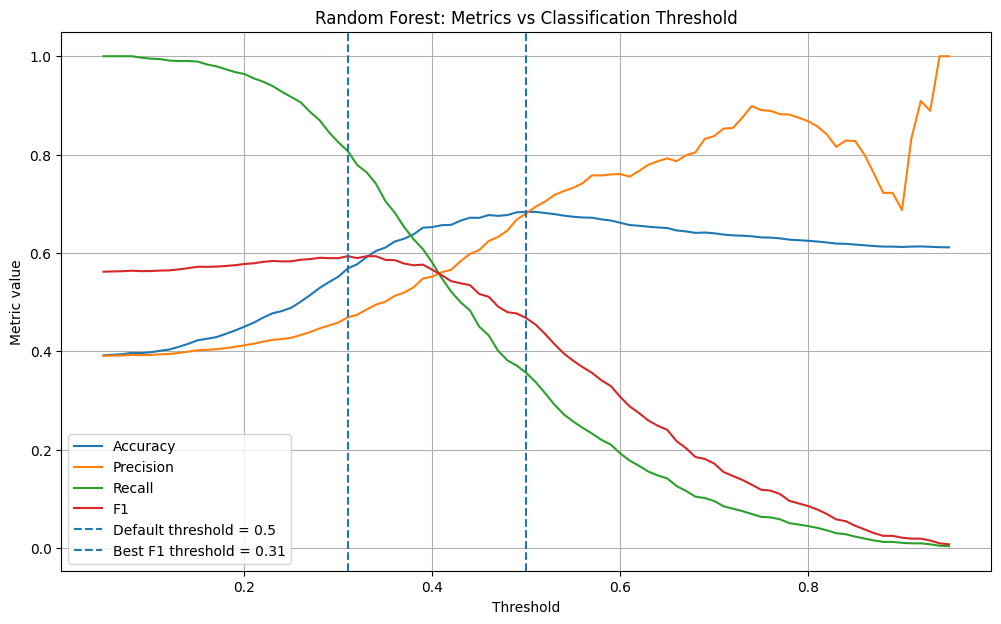

In [ ]:
from sklearn.model_selection import cross_val_predict

rf_oof_proba = cross_val_predict(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

accuracy_values_rf = []
precision_values_rf = []
recall_values_rf = []
f1_values_rf = []

for threshold in thresholds:

    y_pred_threshold = (rf_oof_proba >= threshold).astype(int)

    accuracy_values_rf.append(
        accuracy_score(y_train, y_pred_threshold))

    precision_values_rf.append(
        precision_score(y_train, y_pred_threshold, zero_division=0))

    recall_values_rf.append(
        recall_score(y_train, y_pred_threshold))

    f1_values_rf.append(
        f1_score(y_train, y_pred_threshold))

    best_idx_rf = np.argmax(f1_values_rf)

best_threshold_rf = thresholds[best_idx_rf]

print("Best threshold:", round(best_threshold_rf, 3))
print("Best F1:", round(f1_values_rf[best_idx_rf], 3))
print("Precision:", round(precision_values_rf[best_idx_rf], 3))
print("Recall:", round(recall_values_rf[best_idx_rf], 3))
print("Accuracy:", round(accuracy_values_rf[best_idx_rf], 3))

#Строим график
plt.figure(figsize=(12, 7))
plt.plot(
    thresholds,
    accuracy_values_rf,
    label="Accuracy")
plt.plot(
    thresholds,
    precision_values_rf,
    label="Precision")
plt.plot(
    thresholds,
    recall_values_rf,
    label="Recall")
plt.plot(
    thresholds,
    f1_values_rf,
    label="F1")
plt.axvline(
    x=0.5,
    linestyle="--",
    label="Default threshold = 0.5")
plt.axvline(
    x=best_threshold_rf,
    linestyle="--",
    label=f"Best F1 threshold = {best_threshold_rf:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Random Forest: Metrics vs Classification Threshold")
plt.legend()
plt.grid()
plt.show()

## 9. РЕАЛИЗАЦИЯ STACKING

In [ ]:
#Реализуем метод stacking
from sklearn.ensemble import StackingClassifier

#Задаём базовые модели
tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))])

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        max_features=None,
        random_state=42))])

gb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", GradientBoostingClassifier(
        n_estimators=75,
        learning_rate=0.1,
        max_depth=5,
        random_state=42))])

#Сам стейкинг
stacking_model = StackingClassifier(
    estimators=[
        ("tree", tree),
        ("rf", rf),
        ("gb", gb)],
    final_estimator=LogisticRegression(random_state=42),
    cv=skf,
    stack_method="predict_proba")

cv_stacking = cross_validate(
    stacking_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1)

#Добавляем результаты в таблицу
metrics_cv["St Tr"] = [
    cv_stacking["train_Accuracy"].mean(),
    cv_stacking["train_Precision"].mean(),
    cv_stacking["train_Recall"].mean(),
    cv_stacking["train_F1"].mean(),
    cv_stacking["train_ROC-AUC"].mean()]

metrics_cv["St Val"] = [
    cv_stacking["test_Accuracy"].mean(),
    cv_stacking["test_Precision"].mean(),
    cv_stacking["test_Recall"].mean(),
    cv_stacking["test_F1"].mean(),
    cv_stacking["test_ROC-AUC"].mean()]

metrics_cv.round(3)

,LogReg Tr,LogReg Val,SVM Tr,SVM Val,Tree Tr,Tree Val,Bagging Tr,Bagging Val,RF Tr,RF Val,AB Tr,AB Val,GB Tr,GB Val,XGB Tr,XGB Val,St Tr,St Val
Accuracy,0.611,0.610,0.732,0.674,1.0,0.584,1.0,0.676,0.974,0.684,0.623,0.622,0.866,0.661,0.933,0.673,0.965,0.682
Precision,0.543,0.100,0.850,0.703,1.0,0.467,1.0,0.643,1.000,0.680,0.742,0.730,0.985,0.626,0.979,0.634,1.000,0.688
Recall,0.004,0.002,0.382,0.286,1.0,0.476,1.0,0.379,0.934,0.356,0.052,0.049,0.667,0.327,0.847,0.383,0.910,0.336
F1,0.007,0.003,0.527,0.406,1.0,0.471,1.0,0.476,0.966,0.467,0.097,0.092,0.795,0.428,0.908,0.475,0.953,0.450
ROC-AUC,0.532,0.500,0.806,0.688,1.0,0.564,1.0,0.692,1.000,0.694,0.587,0.570,0.971,0.653,0.991,0.688,1.000,0.690


In [77]:
# Финальный подбор архитектуры Stacking
from itertools import combinations

# 1. Лучшие модели первого уровня Используем best_estimator_ из предыдущих GridSearchCV
base_models = {
    "Bagging": grid_bagging.best_estimator_,
    "RF": grid_rf.best_estimator_,
    "AdaBoost": grid_ada.best_estimator_,
    "GB": grid_gb.best_estimator_,
    "XGB": grid_xgb.best_estimator_}

# 2. Генерируем все комбинации по 3 базовые модели
base_combinations = []

for combo in combinations(base_models.items(), 3):

    estimators = [
        (name, clone(model))
        for name, model in combo]

    base_combinations.append(estimators)

# 3. Мета-модели
meta_models = [
    LogisticRegression(
        random_state=42,
        max_iter=1000),

    DecisionTreeClassifier(
        random_state=42),

    clone(grid_xgb.best_estimator_)]

# 4. Шаблон Stacking
stacking_template = StackingClassifier(
    estimators=base_combinations[0],
    final_estimator=LogisticRegression(
        random_state=42,
        max_iter=1000),
    cv=skf,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1)

# 5. Формируем GridSearch: все комбинации 3 базовых моделей × все 3 мета-модели
param_grid_stacking = []

for estimators in base_combinations:

    for meta_model in meta_models:

        param_grid_stacking.append({
            "estimators": [estimators],
            "final_estimator": [clone(meta_model)]})

# 6. GridSearchCV
grid_stacking = GridSearchCV(
    estimator=stacking_template,
    param_grid=param_grid_stacking,
    cv=skf,
    scoring=scoring,
    refit="ROC-AUC",
    return_train_score=True,
    n_jobs=-1)

grid_stacking.fit(X_train, y_train)

# 7. Лучший вариант
best_stack_params = grid_stacking.best_params_

print("Лучшие базовые модели:",
    [
        name
        for name, model
        in best_stack_params["estimators"]])

print("Лучшая мета-модель:",type(best_stack_params["final_estimator"]).__name__)

print("Лучший Validation ROC-AUC:", round(grid_stacking.best_score_, 3))

Лучшие базовые модели: ['Bagging', 'RF', 'XGB']
Лучшая мета-модель: LogisticRegression
Лучший Validation ROC-AUC: 0.699


In [79]:
best_idx_stack = grid_stacking.best_index_
results_stack = grid_stacking.cv_results_

metrics_cv["St2 Tr"] = [
    results_stack["mean_train_Accuracy"][best_idx_stack],
    results_stack["mean_train_Precision"][best_idx_stack],
    results_stack["mean_train_Recall"][best_idx_stack],
    results_stack["mean_train_F1"][best_idx_stack],
    results_stack["mean_train_ROC-AUC"][best_idx_stack]]

metrics_cv["St2 Val"] = [
    results_stack["mean_test_Accuracy"][best_idx_stack],
    results_stack["mean_test_Precision"][best_idx_stack],
    results_stack["mean_test_Recall"][best_idx_stack],
    results_stack["mean_test_F1"][best_idx_stack],
    results_stack["mean_test_ROC-AUC"][best_idx_stack]]

metrics_val = metrics_cv.filter(like="Val")

metrics_val.round(3)

,LogReg Val,SVM Val,Tree Val,Bagging Val,RF Val,AB Val,GB Val,XGB Val,St Val,St2 Val
Accuracy,0.610,0.674,0.584,0.676,0.684,0.622,0.661,0.673,0.682,0.682
Precision,0.100,0.703,0.467,0.643,0.680,0.730,0.626,0.634,0.688,0.672
Recall,0.002,0.286,0.476,0.379,0.356,0.049,0.327,0.383,0.336,0.365
F1,0.003,0.406,0.471,0.476,0.467,0.092,0.428,0.475,0.450,0.471
ROC-AUC,0.500,0.688,0.564,0.692,0.694,0.570,0.653,0.688,0.690,0.699


## 10. ПОСТРОЕНИЕ ROC-КРИВЫХ ДЛЯ ВСЕХ МОДЕЛЕЙ

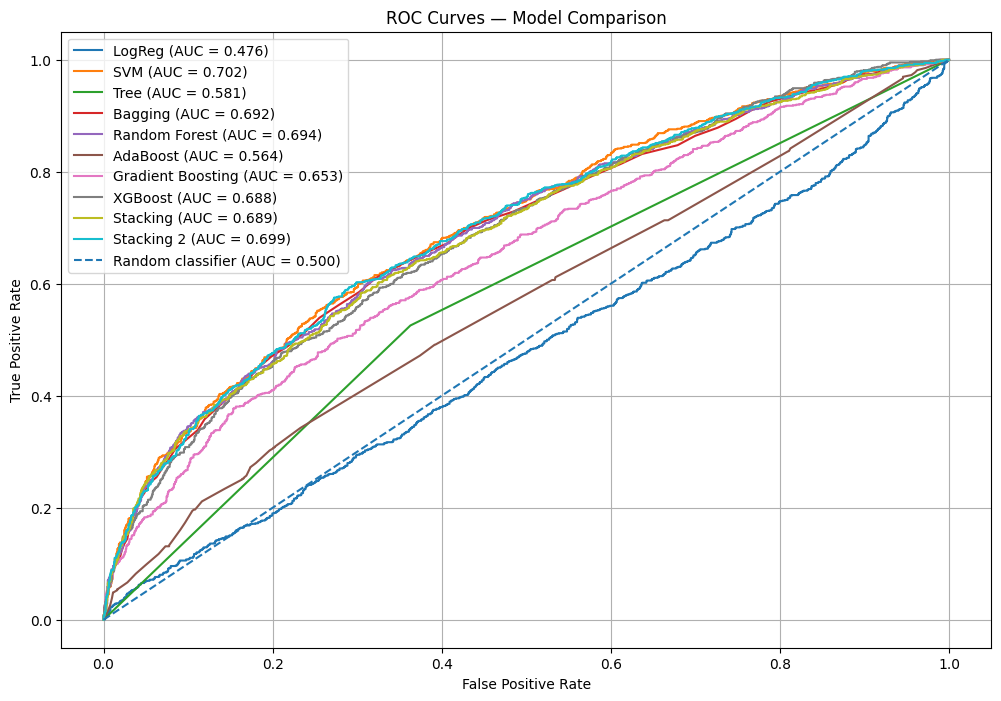

In [80]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
proba_logreg = cross_val_predict(
    model_logreg,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# SVM
score_svm = cross_val_predict(
    model_svm,
    X_train,
    y_train,
    cv=skf,
    method="decision_function",
    n_jobs=-1)

# Decision Tree
proba_tree = cross_val_predict(
    model_tree,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# Bagging
proba_bagging = cross_val_predict(
    grid_bagging.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# Random Forest
proba_rf = cross_val_predict(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# AdaBoost
proba_ab = cross_val_predict(
    grid_ada.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# Gradient Boosting
proba_gb = cross_val_predict(
    grid_gb.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# XGBoost
proba_xgb = cross_val_predict(
    grid_xgb.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# Stacking 1
proba_st = cross_val_predict(
    stacking_model,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# Stacking 2
proba_st2 = cross_val_predict(
    grid_stacking.best_estimator_,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=-1)[:, 1]

# Теперь собираем все модели в один словарь
roc_models = {
    "LogReg": proba_logreg,
    "SVM": score_svm,
    "Tree": proba_tree,
    "Bagging": proba_bagging,
    "Random Forest": proba_rf,
    "AdaBoost": proba_ab,
    "Gradient Boosting": proba_gb,
    "XGBoost": proba_xgb,
    "Stacking": proba_st,
    "Stacking 2": proba_st2}

#строим общие ROC-кривые
plt.figure(figsize=(12, 8))

for name, scores in roc_models.items():

    fpr, tpr, thresholds = roc_curve(
        y_train,
        scores)

    auc = roc_auc_score(
        y_train,
        scores)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})")

# Линия случайного классификатора
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")

plt.legend()
plt.grid()

plt.show()

## 11. ИТОГОВЫЙ ВЫВОД

Для данного датасета наиболее эффективным и одновременно достаточно интерпретируемым решением оказался Random Forest, однако его преимущество над Bagging минимально. Поэтому при сопоставимом качестве выбор между ними может дополнительно учитывать вычислительную сложность, устойчивость результатов и требования к интерпретируемости модели.

Гиперпараметры ансамблевых моделей напрямую влияют на компромисс между смещением (bias) и разбросом (variance). Увеличение глубины деревьев (max_depth) обычно снижает bias, поскольку модель становится сложнее, но одновременно повышает variance и риск переобучения. В Bagging и Random Forest увеличение n_estimators в первую очередь способствует снижению variance и стабилизации модели за счёт усреднения большего числа деревьев. В boosting параметры learning_rate и n_estimators работают совместно: меньший learning_rate делает обучение более постепенным и обычно требует большего количества деревьев, тогда как слишком сложные деревья или чрезмерное число итераций могут привести к переобучению. Параметры subsample, max_features и colsample_bytree добавляют случайность в обучение отдельных моделей ансамбля, уменьшая их коррелированность и тем самым помогая контролировать variance.

Для задач подобного типа практическая рекомендация заключается в том, чтобы начинать с относительно простых базовых моделей и только затем переходить к ансамблям. Если одиночное дерево обладает высокой variance, Bagging или Random Forest являются естественными кандидатами, поскольку позволяют значительно повысить устойчивость модели. Boosting целесообразно использовать при более тщательной настройке сложности базовых деревьев, learning rate и количества итераций. Более сложные методы, такие как XGBoost или Stacking, не следует считать автоматически лучшими: их преимущество необходимо подтверждать на валидационных данных, поскольку в данном эксперименте более простой Random Forest показал качество не хуже более сложных ансамблей.

Также было установлено, что выбор стандартного порога классификации 0.5 не всегда является оптимальным. Например, для Random Forest при подборе порога максимальный F1 достигался примерно при пороге 0.31, при этом Recall увеличивался а Precision снижался. Это показывает, что окончательный выбор модели должен учитывать не только ROC-AUC, но и требуемый бизнесом баланс Precision и Recall.

Отдельно был исследован Stacking. Первый вариант, объединяющий Decision Tree, Random Forest и Gradient Boosting с Logistic Regression в качестве мета-модели, показал ROC-AUC около 0.690. Дополнительный перебор различных комбинаций базовых и мета-моделей позволил улучшить результат до 0.699, что стало лучшим значением ROC-AUC среди рассмотренных моделей. При этом преимущество над Random Forest (0.694) и Bagging (0.692) оказалось небольшим. Это показывает, что stacking способен получить дополнительный прирост за счёт объединения прогнозов различных алгоритмов, однако в данном случае усложнение архитектуры даёт лишь незначительное улучшение качества. Поэтому его использование оправдано, если приоритетом является максимизация качества, тогда как Random Forest или Bagging остаются более простыми альтернативами с практически сопоставимым результатом.